# 6.2 - Multi-dataset benchmark analysis

This notebook analyses the benchmark parquet files produced by `scripts/benchmark.py` across multiple tabular datasets.

**Current sections**
1. Load and overview
2. Validity
3. Proximity

Distances, sparsity, and related quality metrics are always interpreted **only on valid counterfactuals**.

In [24]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

REPO_ROOT = Path("..").resolve()
SRC_ROOT = REPO_ROOT / "src"
DATA_ROOT = REPO_ROOT / "data"
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

sns.set_theme(style="whitegrid", palette="tab10")
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (10, 4)})

RESULT_FILES = {
    "Adult": Path("../results/benchmark_adult_meeting.parquet"),
    "COMPAS": Path("../results/benchmark_compas_meeting.parquet"),
    "German Credit": Path("../results/benchmark_german_credit_meeting.parquet"),
    "HELOC": Path("../results/benchmark_heloc_meeting.parquet"),
    # "Give Me Some Credit": Path("../results/benchmark_give_me_some_credit_meeting.parquet"),
    "Lending Club": Path("../results/benchmark_lending_club_meeting.parquet"),
}

METHOD_LABELS = {
    "nn": "Nearest Neighbor",
    "dice": "DiCE",
    "gs": "Growing Spheres",
    "face": "FACE",
    "cpp": "Our method",
}

dataset_order = list(RESULT_FILES.keys())


## 1. Load and overview

In [25]:
def load_available_results(files):
    frames = []
    status_rows = []
    for dataset_name, path in files.items():
        exists = path.exists()
        status_rows.append({"dataset": dataset_name, "path": str(path), "available": exists})
        if exists:
            df_part = pd.read_parquet(path).copy()
            df_part["dataset"] = dataset_name
            frames.append(df_part)
    status_df = pd.DataFrame(status_rows)
    if not frames:
        raise RuntimeError("No benchmark parquet files were found.")
    df_all = pd.concat(frames, ignore_index=True)
    df_all["method_label"] = df_all["method"].map(METHOD_LABELS).fillna(df_all["method"])
    return df_all, status_df


df, status_df = load_available_results(RESULT_FILES)

display(status_df)
print("Loaded datasets:", sorted(df["dataset"].unique()))
print("Methods:", sorted(df["method_label"].unique()))
print("Rows:", len(df))


,dataset,path,available
0,Adult,../results/benchmark_adult_meeting.parquet,True
1,COMPAS,../results/benchmark_compas_meeting.parquet,True
2,German Credit,../results/benchmark_german_credit_meeting.par...,True
3,HELOC,../results/benchmark_heloc_meeting.parquet,True
4,Lending Club,../results/benchmark_lending_club_meeting.parquet,True


Loaded datasets: ['Adult', 'COMPAS', 'German Credit', 'HELOC', 'Lending Club']
Methods: ['DiCE', 'FACE', 'Growing Spheres', 'Nearest Neighbor', 'Our method']
Rows: 1250


In [26]:
overview = (
    df.groupby(["dataset", "method_label"])
    .agg(
        n_queries=("success", "size"),
        validity_pct=("success", lambda s: 100.0 * s.mean()),
        mean_runtime_s=("runtime_s", "mean"),
    )
    .reset_index()
)

display(overview)


,dataset,method_label,n_queries,validity_pct,mean_runtime_s
0,Adult,DiCE,50,100.0,4.843065
1,Adult,FACE,50,40.0,0.003276
2,Adult,Growing Spheres,50,80.0,0.021852
3,Adult,Nearest Neighbor,50,100.0,0.001431
4,Adult,Our method,50,100.0,0.087769
5,COMPAS,DiCE,50,94.0,2.398364
6,COMPAS,FACE,50,94.0,0.018765
7,COMPAS,Growing Spheres,50,100.0,0.002739
8,COMPAS,Nearest Neighbor,50,100.0,0.000111
9,COMPAS,Our method,50,100.0,0.036591


## 2. Validity

Validity measures whether a counterfactual is classified in the desired target class.

To compare methods more informatively than with a single percentage, we plot validity as a function of an allowed L2 distance budget. For each method, the curve shows the fraction of queries for which a valid counterfactual is found within a given distance. Failed queries are treated as having infinite distance, so the plateau of each curve coincides with the overall validity.

This plot should be read as follows:
- a higher plateau means higher overall validity
- a steeper early rise means valid counterfactuals are found with smaller changes

In [27]:
method_order = (
    df.groupby("method_label")["success"]
    .mean()
    .sort_values(ascending=False)
    .index
    .tolist()
)
palette = dict(zip(method_order, sns.color_palette("tab10", len(method_order))))

validity_table = (
    df.groupby(["method_label", "dataset"])["success"]
    .mean()
    .mul(100)
    .unstack("dataset")
    .reindex(method_order)
)

display(validity_table.style.format("{:.1f}%").background_gradient(cmap="YlGn"))


dataset,Adult,COMPAS,German Credit,HELOC,Lending Club
method_label,,,,,
Our method,100.0%,100.0%,100.0%,100.0%,100.0%
Nearest Neighbor,100.0%,100.0%,100.0%,100.0%,100.0%
DiCE,100.0%,94.0%,84.0%,100.0%,100.0%
Growing Spheres,80.0%,100.0%,62.0%,92.0%,100.0%
FACE,40.0%,94.0%,6.0%,72.0%,88.0%


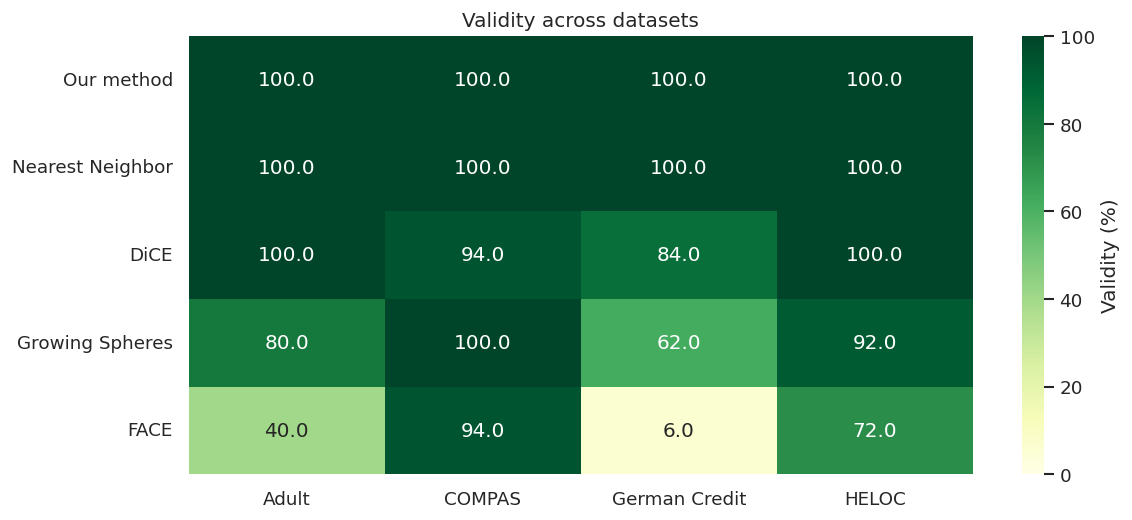

In [23]:
plt.figure(figsize=(10, 4.5))
sns.heatmap(
    validity_table,
    annot=True,
    fmt=".1f",
    cmap="YlGn",
    vmin=0,
    vmax=100,
    cbar_kws={"label": "Validity (%)"},
)
plt.title("Validity across datasets")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.show()


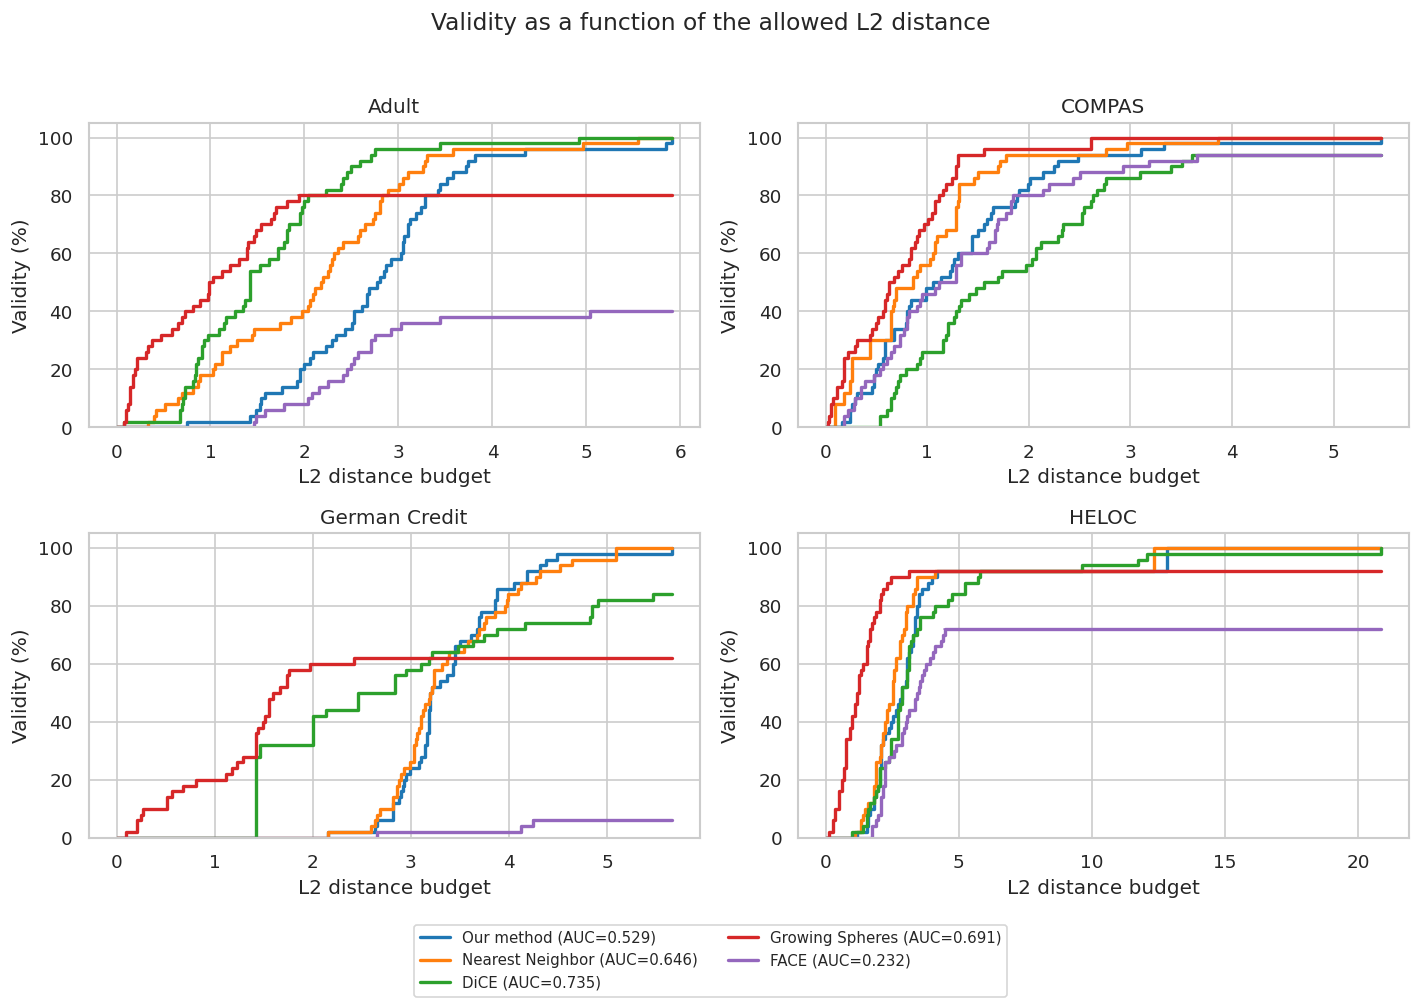

In [6]:
def validity_proximity_curve(distances, eps_grid=None, n_thresholds=300):
    distances = np.asarray(distances, dtype=float)
    finite = np.sort(distances[np.isfinite(distances)])
    max_finite = float(finite.max()) if finite.size else 0.0

    if eps_grid is None:
        eps_grid = np.linspace(0.0, max_finite, n_thresholds) if max_finite > 0 else np.array([0.0])
    else:
        eps_grid = np.asarray(eps_grid, dtype=float)

    success_curve = np.searchsorted(finite, eps_grid, side="right") / len(distances)
    plateau_pct = 100.0 * finite.size / len(distances)

    if eps_grid.size > 1 and eps_grid[-1] > 0:
        area = np.trapezoid(success_curve, eps_grid)
        auc = area / eps_grid[-1]
    else:
        auc = plateau_pct / 100.0

    return eps_grid, 100.0 * success_curve, plateau_pct, auc, max_finite


datasets_here = [d for d in dataset_order if d in df["dataset"].unique()]
n = len(datasets_here)
ncols = 2
nrows = int(np.ceil(n / ncols))

curve_rows = []
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4.2 * nrows), squeeze=False)
axes = axes.ravel()

for ax, dataset_name in zip(axes, datasets_here):
    sub_ds = df[df["dataset"] == dataset_name].copy()

    finite_l2 = sub_ds.loc[sub_ds["success"], "l2_distance"].to_numpy(dtype=float)
    finite_l2 = finite_l2[np.isfinite(finite_l2)]
    max_l2 = float(finite_l2.max()) if finite_l2.size else 0.0
    eps_grid = np.linspace(0.0, max_l2, 300) if max_l2 > 0 else np.array([0.0])

    for method in method_order:
        sub_m = sub_ds[sub_ds["method_label"] == method]
        if sub_m.empty:
            continue

        distances = sub_m["l2_distance"].to_numpy(dtype=float)
        success_mask = sub_m["success"].to_numpy(dtype=bool)
        distances[~success_mask] = np.inf
        distances[~np.isfinite(distances)] = np.inf

        x, y, plateau, auc, max_finite = validity_proximity_curve(distances, eps_grid=eps_grid)

        ax.step(x, y, where="post", linewidth=2, color=palette[method], label=f"{method} (AUC={auc:.3f})")
        ax.hlines(
            plateau,
            xmin=max_finite,
            xmax=eps_grid[-1] if eps_grid.size else 0.0,
            colors=palette[method],
            linestyles="--",
            linewidth=1.2,
            alpha=0.45,
        )

        curve_rows.append({
            "dataset": dataset_name,
            "method": method,
            "max_validity_pct": plateau,
            "auc_norm": auc,
        })

    ax.set_title(dataset_name)
    ax.set_xlabel("L2 distance budget")
    ax.set_ylabel("Validity (%)")
    ax.set_ylim(0, 105)

for ax in axes[n:]:
    ax.axis("off")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2, fontsize=9, frameon=True)
fig.suptitle("Validity as a function of the allowed L2 distance", fontsize=14)
plt.tight_layout(rect=[0, 0.08, 1, 0.96])
plt.show()


In [7]:
curve_summary = (
    pd.DataFrame(curve_rows)
    .pivot(index="method", columns="dataset", values="auc_norm")
    .reindex(method_order)
)

display(curve_summary.style.format("{:.3f}").background_gradient(cmap="Blues"))


dataset,Adult,COMPAS,German Credit,HELOC
method,,,,
Our method,0.529,0.768,0.400,0.835
Nearest Neighbor,0.646,0.827,0.401,0.848
DiCE,0.735,0.648,0.463,0.820
Growing Spheres,0.691,0.867,0.492,0.868
FACE,0.232,0.729,0.021,0.620


Validity should be interpreted before all other metrics: proximity and sparsity are only meaningful when the counterfactual is valid.

In the plots above:
- the final plateau corresponds to the total validity of the method
- curves that rise earlier indicate methods that achieve valid counterfactuals with smaller perturbations
- the normalized AUC provides a compact summary of this validity-proximity trade-off

## 3. Proximity

After checking validity, we compare proximity **only on valid counterfactuals**.

Proximity measures how far a successful counterfactual is from the original instance. We report both L1 and L2 distances:
- L1 captures the total amount of change across features
- L2 captures the overall Euclidean magnitude of the change

Lower values indicate counterfactuals that stay closer to the original point.

In [8]:
df_ok = df[df["success"]].copy()

valid_counts = (
    df_ok.groupby(["dataset", "method_label"])
    .size()
    .unstack(fill_value=0)
)

display(valid_counts)


method_label,DiCE,FACE,Growing Spheres,Nearest Neighbor,Our method
dataset,,,,,
Adult,50,20,40,50,50
COMPAS,47,47,50,50,50
German Credit,42,3,31,50,50
HELOC,50,36,46,50,50


In [9]:
l1_table = (
    df_ok.groupby(["method_label", "dataset"])["l1_distance"]
    .mean()
    .unstack("dataset")
    .reindex(method_order)
)

l2_table = (
    df_ok.groupby(["method_label", "dataset"])["l2_distance"]
    .mean()
    .unstack("dataset")
    .reindex(method_order)
)

print("Mean L1 distance on valid counterfactuals")
display(l1_table.style.format("{:.3f}").background_gradient(cmap="Blues_r"))

print("Mean L2 distance on valid counterfactuals")
display(l2_table.style.format("{:.3f}").background_gradient(cmap="Blues_r"))


Mean L1 distance on valid counterfactuals


dataset,Adult,COMPAS,German Credit,HELOC
method_label,,,,
Our method,8.132,2.059,11.668,12.872
Nearest Neighbor,4.551,1.144,10.487,10.353
DiCE,1.832,2.227,7.492,5.615
Growing Spheres,1.118,1.114,2.173,2.728
FACE,6.090,2.008,12.414,9.840


Mean L2 distance on valid counterfactuals


dataset,Adult,COMPAS,German Credit,HELOC
method_label,,,,
Our method,2.782,1.269,3.396,3.448
Nearest Neighbor,2.093,0.944,3.388,3.170
DiCE,1.565,1.695,2.543,3.768
Growing Spheres,0.807,0.727,1.171,1.165
FACE,2.483,1.228,3.661,2.911


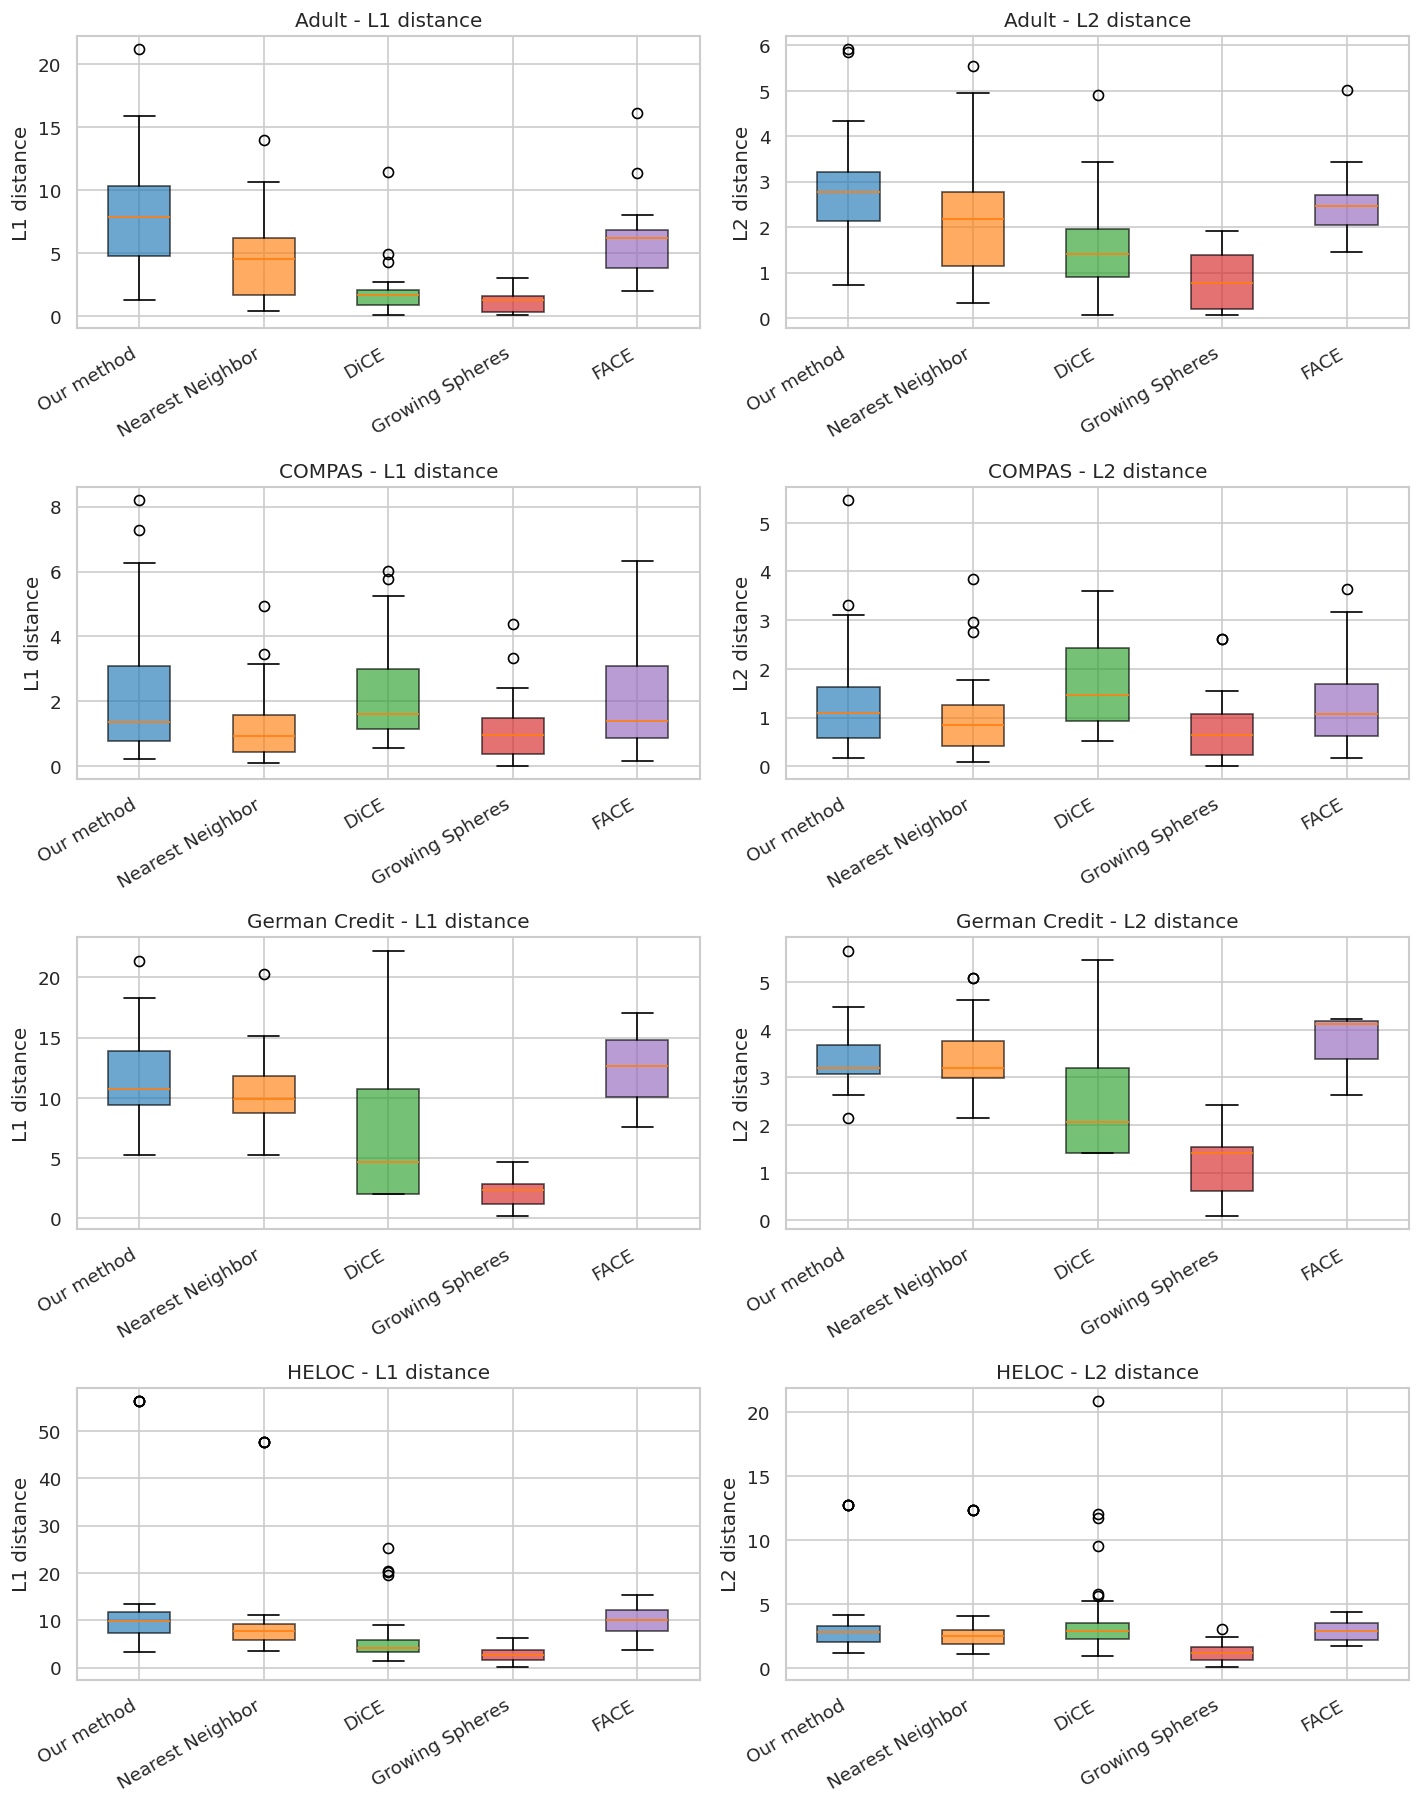

In [10]:
datasets_here = [d for d in dataset_order if d in df_ok["dataset"].unique()]
n = len(datasets_here)
fig, axes = plt.subplots(n, 2, figsize=(12, 3.8 * n), squeeze=False)

for i, dataset_name in enumerate(datasets_here):
    sub = df_ok[df_ok["dataset"] == dataset_name]
    methods_here = [m for m in method_order if m in sub["method_label"].unique()]
    colors_here = [palette[m] for m in methods_here]

    data_l1 = [sub[sub["method_label"] == m]["l1_distance"].dropna().values for m in methods_here]
    bp1 = axes[i, 0].boxplot(data_l1, vert=True, patch_artist=True, tick_labels=methods_here)
    for patch, color in zip(bp1["boxes"], colors_here):
        patch.set_facecolor(color)
        patch.set_alpha(0.65)
    axes[i, 0].set_title(f"{dataset_name} - L1 distance")
    axes[i, 0].set_ylabel("L1 distance")
    axes[i, 0].set_xticklabels(methods_here, rotation=30, ha="right")

    data_l2 = [sub[sub["method_label"] == m]["l2_distance"].dropna().values for m in methods_here]
    bp2 = axes[i, 1].boxplot(data_l2, vert=True, patch_artist=True, tick_labels=methods_here)
    for patch, color in zip(bp2["boxes"], colors_here):
        patch.set_facecolor(color)
        patch.set_alpha(0.65)
    axes[i, 1].set_title(f"{dataset_name} - L2 distance")
    axes[i, 1].set_ylabel("L2 distance")
    axes[i, 1].set_xticklabels(methods_here, rotation=30, ha="right")

plt.tight_layout()
plt.show()


In [11]:
prox_summary = (
    df_ok.groupby("method_label")
    .agg(
        mean_l1=("l1_distance", "mean"),
        std_l1=("l1_distance", "std"),
        mean_l2=("l2_distance", "mean"),
        std_l2=("l2_distance", "std"),
        n_valid=("success", "size"),
    )
    .reindex(method_order)
)

display(
    prox_summary.style.format({
        "mean_l1": "{:.3f}",
        "std_l1": "{:.3f}",
        "mean_l2": "{:.3f}",
        "std_l2": "{:.3f}",
        "n_valid": "{:d}",
    })
)


,mean_l1,std_l1,mean_l2,std_l2,n_valid
method_label,,,,,
Our method,8.683,8.238,2.724,1.830,200
Nearest Neighbor,6.634,7.151,2.399,1.848,200
DiCE,4.189,4.719,2.398,2.103,189
Growing Spheres,1.756,1.337,0.950,0.638,167
FACE,5.733,4.450,2.105,1.148,106


These proximity values are computed only on valid counterfactuals.

This is important: a method should not be rewarded for staying close to the original point if it fails to reach the target class. Proximity therefore complements validity rather than replacing it.

## 4. Sparsity

We now compare sparsity **only on valid counterfactuals**.

Sparsity measures the fraction of features that change between the original instance and the counterfactual. Lower values indicate simpler explanations, since fewer input dimensions need to be modified to reach the target class.

In [12]:
sparsity_table = (
    df_ok.groupby(["method_label", "dataset"])["l0_sparsity"]
    .mean()
    .mul(100)
    .unstack("dataset")
    .reindex(method_order)
)

display(sparsity_table.style.format("{:.1f}%").background_gradient(cmap="Blues_r"))


dataset,Adult,COMPAS,German Credit,HELOC
method_label,,,,
Our method,9.0%,24.9%,20.9%,77.0%
Nearest Neighbor,5.1%,16.0%,18.2%,66.3%
DiCE,2.6%,24.2%,15.5%,19.6%
Growing Spheres,2.6%,20.6%,6.8%,29.1%
FACE,6.3%,25.1%,21.9%,73.4%


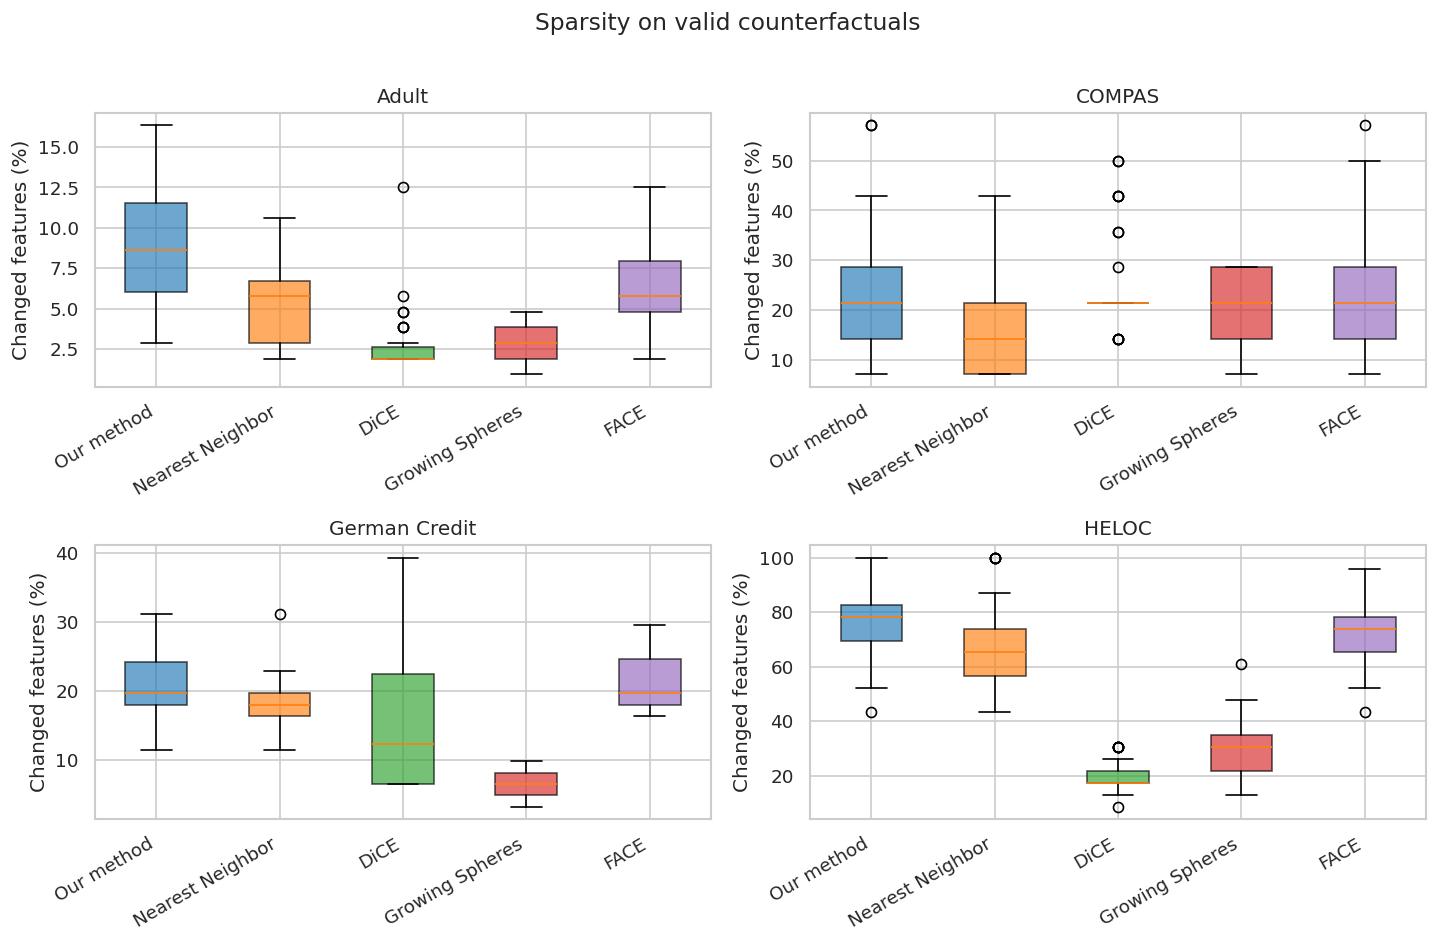

In [13]:
datasets_here = [d for d in dataset_order if d in df_ok["dataset"].unique()]
n = len(datasets_here)
ncols = 2
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4.0 * nrows), squeeze=False)
axes = axes.ravel()

for ax, dataset_name in zip(axes, datasets_here):
    sub = df_ok[df_ok["dataset"] == dataset_name]
    methods_here = [m for m in method_order if m in sub["method_label"].unique()]
    colors_here = [palette[m] for m in methods_here]
    data = [100.0 * sub[sub["method_label"] == m]["l0_sparsity"].dropna().values for m in methods_here]

    bp = ax.boxplot(data, vert=True, patch_artist=True, tick_labels=methods_here)
    for patch, color in zip(bp["boxes"], colors_here):
        patch.set_facecolor(color)
        patch.set_alpha(0.65)

    ax.set_title(dataset_name)
    ax.set_ylabel("Changed features (%)")
    ax.set_xticklabels(methods_here, rotation=30, ha="right")

for ax in axes[n:]:
    ax.axis("off")

fig.suptitle("Sparsity on valid counterfactuals", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


In [14]:
sparsity_summary = (
    df_ok.groupby("method_label")
    .agg(
        mean_sparsity=("l0_sparsity", lambda s: 100.0 * s.mean()),
        std_sparsity=("l0_sparsity", lambda s: 100.0 * s.std()),
        n_valid=("success", "size"),
    )
    .reindex(method_order)
)

display(
    sparsity_summary.style.format({
        "mean_sparsity": "{:.1f}%",
        "std_sparsity": "{:.1f}%",
        "n_valid": "{:d}",
    })
)


,mean_sparsity,std_sparsity,n_valid
method_label,,,
Our method,32.9%,27.8%,200
Nearest Neighbor,26.4%,25.2%,200
DiCE,15.3%,10.7%,189
Growing Spheres,16.1%,12.4%,167
FACE,37.9%,28.4%,106


Sparsity is again evaluated only on valid counterfactuals.

A sparse counterfactual is often easier to interpret, because it suggests a smaller set of changes. However, sparsity should always be read together with validity and proximity: extremely sparse counterfactuals are only useful if they are both valid and reasonably close to the original point.

## 5. Plausibility

Plausibility is not stored in the benchmark parquet files, so we compute it post hoc from the valid counterfactuals and the training data of each dataset.

We use three complementary metrics:
- **k-NN distance**: mean distance to the nearest training points; lower is better
- **LOF score**: Local Outlier Factor score; higher means more in-distribution
- **KDE log-density**: kernel density estimate score; higher means denser and therefore more plausible regions

As in `6.1`, we compare each method against a reference sample drawn directly from the training set.

In [15]:
from counterfactuals.datasets.loaders import (
    AdultDataset,
    CompasDataset,
    GermanCreditDataset,
    GiveMeSomeCreditDataset,
    HELOCDataset,
    LendingClubDataset,
)
from sklearn.neighbors import KernelDensity, LocalOutlierFactor, NearestNeighbors

DATASET_LOADERS = {
    "Adult": lambda: AdultDataset(data_dir=str(DATA_ROOT), seed=42),
    "COMPAS": lambda: CompasDataset(data_dir=str(DATA_ROOT), seed=42),
    "German Credit": lambda: GermanCreditDataset(data_dir=str(DATA_ROOT), seed=42),
    "HELOC": lambda: HELOCDataset(data_dir=str(DATA_ROOT), seed=42),
    "Give Me Some Credit": lambda: GiveMeSomeCreditDataset(data_dir=str(DATA_ROOT), seed=42),
    "Lending Club": lambda: LendingClubDataset(data_dir=str(DATA_ROOT), seed=42),
}

train_cache = {}
for dataset_name in datasets_here:
    ds = DATASET_LOADERS[dataset_name]()
    ds.load()
    x_train_ds, y_train_ds = ds.get_train()
    train_cache[dataset_name] = {"x_train": x_train_ds, "y_train": y_train_ds}
    print(dataset_name, x_train_ds.shape)


Adult (36178, 104)
COMPAS (4938, 14)
German Credit (800, 61)
HELOC (8369, 23)


In [16]:
rng_plaus = np.random.default_rng(42)
plaus_rows = []
ref_rows = []

for dataset_name in datasets_here:
    x_train_ds = np.asarray(train_cache[dataset_name]["x_train"], dtype=np.float32)

    fit_size = min(5000, len(x_train_ds))
    fit_idx = rng_plaus.choice(len(x_train_ds), size=fit_size, replace=False)
    x_fit = x_train_ds[fit_idx]

    ref_size = min(500, len(x_fit))
    ref_idx = rng_plaus.choice(len(x_fit), size=ref_size, replace=False)
    x_ref = x_fit[ref_idx]

    nn_model = NearestNeighbors(n_neighbors=min(5, len(x_fit)))
    nn_model.fit(x_fit)

    lof_model = LocalOutlierFactor(n_neighbors=min(20, max(2, len(x_fit) - 1)), novelty=True)
    lof_model.fit(x_fit)

    kde_model = KernelDensity(kernel="gaussian", bandwidth=1.0)
    kde_model.fit(x_fit)

    ref_knn = nn_model.kneighbors(x_ref, return_distance=True)[0].mean(axis=1)
    ref_lof = lof_model.score_samples(x_ref)
    ref_kde = kde_model.score_samples(x_ref)

    ref_rows.extend(
        [{"dataset": dataset_name, "metric": "knn_distance", "value": float(v), "label": "[train ref]"} for v in ref_knn]
    )
    ref_rows.extend(
        [{"dataset": dataset_name, "metric": "lof_score", "value": float(v), "label": "[train ref]"} for v in ref_lof]
    )
    ref_rows.extend(
        [{"dataset": dataset_name, "metric": "kde_log_density", "value": float(v), "label": "[train ref]"} for v in ref_kde]
    )

    sub_ds = df_ok[df_ok["dataset"] == dataset_name]
    methods_here = [m for m in method_order if m in sub_ds["method_label"].unique()]

    for method in methods_here:
        sub_m = sub_ds[sub_ds["method_label"] == method]
        cols_here = sorted(
            [c for c in sub_m.columns if c.startswith("x_cf_") and not sub_m[c].isna().all()],
            key=lambda c: int(c.split("_")[-1]),
        )
        x_cf = sub_m[cols_here].to_numpy(dtype=np.float32)
        x_cf = x_cf[~np.isnan(x_cf).any(axis=1)]
        if len(x_cf) == 0:
            continue

        knn_dist = nn_model.kneighbors(x_cf, return_distance=True)[0].mean(axis=1)
        lof_score = lof_model.score_samples(x_cf)
        kde_log_density = kde_model.score_samples(x_cf)

        for v in knn_dist:
            plaus_rows.append({"dataset": dataset_name, "method": method, "metric": "knn_distance", "value": float(v)})
        for v in lof_score:
            plaus_rows.append({"dataset": dataset_name, "method": method, "metric": "lof_score", "value": float(v)})
        for v in kde_log_density:
            plaus_rows.append({"dataset": dataset_name, "method": method, "metric": "kde_log_density", "value": float(v)})

plaus_df = pd.DataFrame(plaus_rows)
ref_df = pd.DataFrame(ref_rows)
print("plausibility rows:", len(plaus_df))
print("reference rows:", len(ref_df))


plausibility rows: 2586
reference rows: 6000


In [17]:
plaus_summary = (
    plaus_df.groupby(["metric", "method", "dataset"])["value"]
    .mean()
    .reset_index()
)

for metric_name in ["knn_distance", "lof_score", "kde_log_density"]:
    print(metric_name)
    table = (
        plaus_summary[plaus_summary["metric"] == metric_name]
        .pivot(index="method", columns="dataset", values="value")
        .reindex(method_order)
    )
    cmap = "Blues_r" if metric_name == "knn_distance" else "Blues"
    display(table.style.format("{:.3f}").background_gradient(cmap=cmap))


knn_distance


dataset,Adult,COMPAS,German Credit,HELOC
method,,,,
Our method,0.823,0.103,2.267,1.358
Nearest Neighbor,1.605,0.215,2.266,1.423
DiCE,2.213,0.950,3.348,3.619
Growing Spheres,1.828,0.456,3.127,2.101
FACE,0.772,0.059,2.008,1.183


lof_score


dataset,Adult,COMPAS,German Credit,HELOC
method,,,,
Our method,-1.025,-1.047,-1.016,-1.005
Nearest Neighbor,-1.192,-1703678.321,-1.020,-1.048
DiCE,-1.372,-3.072,-1.095,-10829309216.050
Growing Spheres,-1.248,-69501935.511,-1.052,-1.153
FACE,-1.008,-1.037,-1.025,-0.989


kde_log_density


dataset,Adult,COMPAS,German Credit,HELOC
method,,,,
Our method,-99.837,-14.707,-62.432,-26.150
Nearest Neighbor,-101.373,-15.013,-62.413,-27.031
DiCE,-102.562,-16.007,-65.579,-37.475
Growing Spheres,-101.766,-15.203,-64.876,-28.061
FACE,-99.589,-14.567,-62.421,-25.614


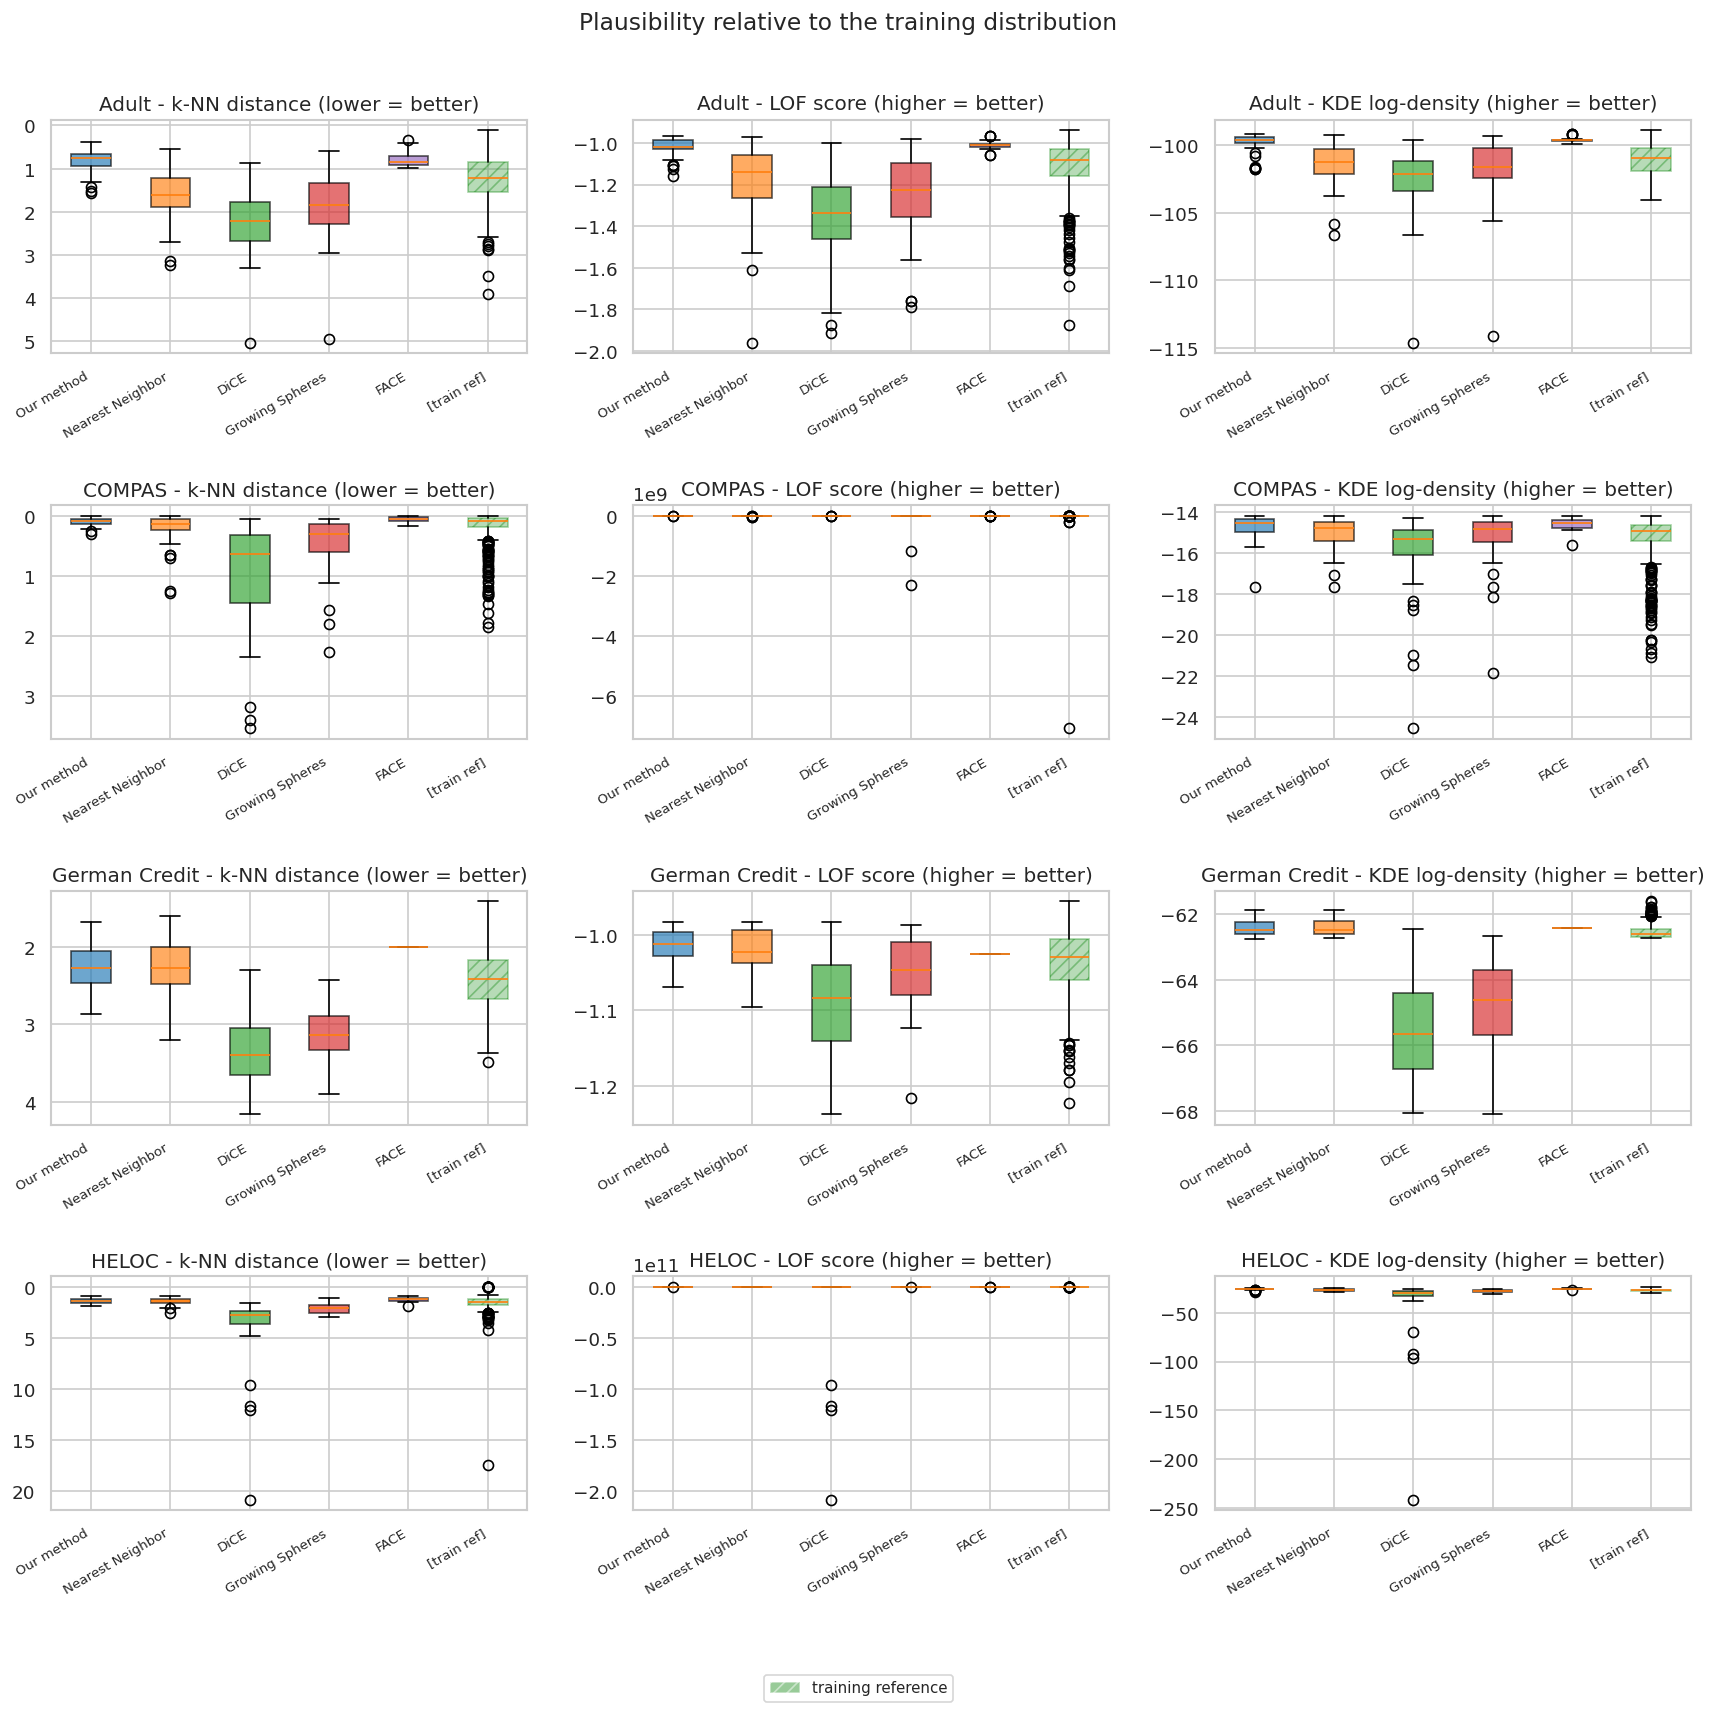

In [18]:
metric_info = [
    ("knn_distance", "k-NN distance (lower = better)", True),
    ("lof_score", "LOF score (higher = better)", False),
    ("kde_log_density", "KDE log-density (higher = better)", False),
]

from matplotlib.patches import Patch

nrows = len(datasets_here)
ncols = len(metric_info)
fig, axes = plt.subplots(nrows, ncols, figsize=(4.8 * ncols, 3.6 * nrows), squeeze=False)

for i, dataset_name in enumerate(datasets_here):
    methods_here = [m for m in method_order if m in plaus_df.loc[plaus_df["dataset"] == dataset_name, "method"].unique()]
    for j, (metric_name, title, invert) in enumerate(metric_info):
        ax = axes[i, j]
        sub_metric = plaus_df[(plaus_df["dataset"] == dataset_name) & (plaus_df["metric"] == metric_name)]
        ref_metric = ref_df[(ref_df["dataset"] == dataset_name) & (ref_df["metric"] == metric_name)]

        data_by_method = [sub_metric[sub_metric["method"] == m]["value"].dropna().values for m in methods_here]
        labels = methods_here + ["[train ref]"]
        data_all = data_by_method + [ref_metric["value"].dropna().values]

        bp = ax.boxplot(data_all, orientation="vertical", patch_artist=True, tick_labels=labels)
        for k, patch in enumerate(bp["boxes"]):
            if k < len(methods_here):
                patch.set_facecolor(palette[methods_here[k]])
                patch.set_alpha(0.65)
            else:
                patch.set_facecolor((0.2, 0.6, 0.2))
                patch.set_alpha(0.35)
                patch.set_hatch("///")
                patch.set_edgecolor("green")

        if invert:
            ax.invert_yaxis()
        ax.set_title(f"{dataset_name} - {title}")
        ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=8)

handles = [Patch(facecolor=(0.2, 0.6, 0.2), hatch='///', alpha=0.5, label='training reference')]
fig.legend(handles=handles, loc="lower center", ncol=1, fontsize=9, frameon=True)
fig.suptitle("Plausibility relative to the training distribution", fontsize=14)
plt.tight_layout(rect=[0, 0.05, 1, 0.97])
plt.show()


These plausibility metrics are computed only on valid counterfactuals.

The training-reference boxes provide a useful anchor: methods whose distributions are closer to the training reference can be interpreted as producing more realistic counterfactuals. As usual, this section should be read together with validity, proximity, and sparsity rather than in isolation.

## 6. Joint validity-closeness score

To summarize validity and proximity in a single quantity, we define a per-query utility that decreases linearly with distance and is zero for failed counterfactuals.

For a fixed L2 budget $B$, the per-query score is

$$u_B(d) = \max\left(1 - \frac{d}{B}, 0\right),$$

where failed counterfactuals are treated as having infinite distance and therefore receive score 0.

Averaging this utility across queries gives the **Validity-Closeness Score (VCS)**. Higher values indicate methods that are both more reliable and closer to the original input.

In [19]:
def validity_closeness_score(distances, budget):
    distances = np.asarray(distances, dtype=float)
    distances = np.where(np.isfinite(distances), distances, np.inf)
    return float(np.mean(np.maximum(1.0 - distances / budget, 0.0)))


vcs_rows = []
budget_rows = []

for dataset_name in datasets_here:
    sub_ds = df[df["dataset"] == dataset_name].copy()
    finite_success = sub_ds.loc[sub_ds["success"], "l2_distance"].to_numpy(dtype=float)
    finite_success = finite_success[np.isfinite(finite_success)]
    if finite_success.size == 0:
        continue

    budget = float(np.quantile(finite_success, 0.95))
    budget_rows.append({"dataset": dataset_name, "l2_budget": budget})

    for method in method_order:
        sub_m = sub_ds[sub_ds["method_label"] == method]
        if sub_m.empty:
            continue

        distances = sub_m["l2_distance"].to_numpy(dtype=float)
        success_mask = sub_m["success"].to_numpy(dtype=bool)
        distances[~success_mask] = np.inf
        distances[~np.isfinite(distances)] = np.inf

        score = validity_closeness_score(distances, budget)
        vcs_rows.append({
            "dataset": dataset_name,
            "method": method,
            "vcs": score,
            "budget": budget,
        })

vcs_df = pd.DataFrame(vcs_rows)
budget_df = pd.DataFrame(budget_rows)
display(budget_df)


,dataset,l2_budget
0,Adult,3.568381
1,COMPAS,2.753264
2,German Credit,4.536952
3,HELOC,7.473193


In [20]:
vcs_table = (
    vcs_df.pivot(index="method", columns="dataset", values="vcs")
    .reindex(method_order)
)

display(vcs_table.style.format("{:.3f}").background_gradient(cmap="YlGn"))


dataset,Adult,COMPAS,German Credit,HELOC
method,,,,
Our method,0.254,0.565,0.256,0.595
Nearest Neighbor,0.432,0.667,0.259,0.628
DiCE,0.569,0.380,0.379,0.561
Growing Spheres,0.619,0.736,0.460,0.777
FACE,0.130,0.532,0.012,0.440


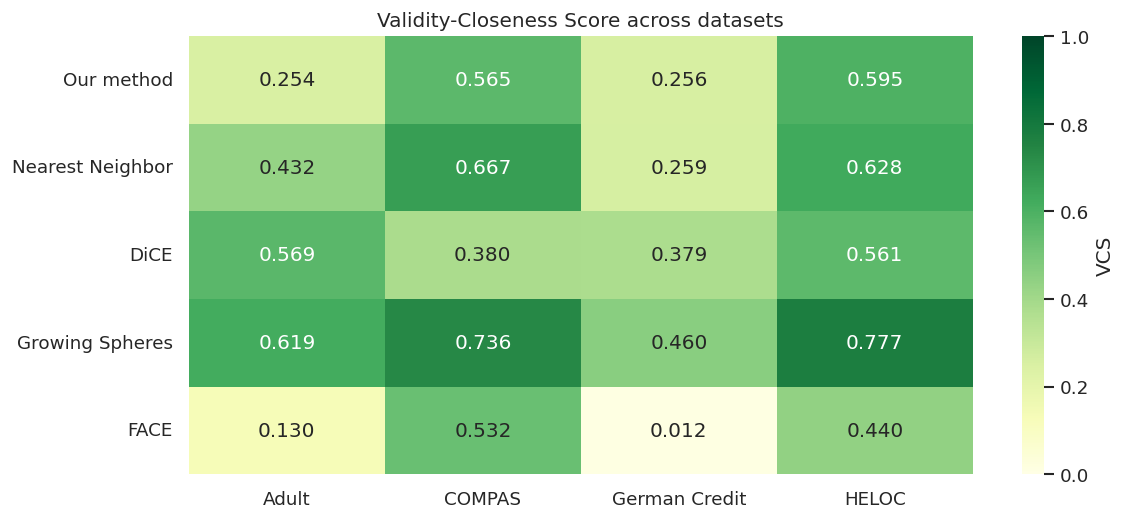

In [21]:
plt.figure(figsize=(10, 4.5))
sns.heatmap(
    vcs_table,
    annot=True,
    fmt=".3f",
    cmap="YlGn",
    vmin=0,
    vmax=1,
    cbar_kws={"label": "VCS"},
)
plt.title("Validity-Closeness Score across datasets")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.show()


In [22]:
vcs_summary = (
    vcs_df.groupby("method")
    .agg(
        mean_vcs=("vcs", "mean"),
        std_vcs=("vcs", "std"),
        n_datasets=("dataset", "size"),
    )
    .reindex(method_order)
)

display(
    vcs_summary.style.format({
        "mean_vcs": "{:.3f}",
        "std_vcs": "{:.3f}",
        "n_datasets": "{:d}",
    })
)


,mean_vcs,std_vcs,n_datasets
method,,,
Our method,0.418,0.188,4
Nearest Neighbor,0.496,0.189,4
DiCE,0.472,0.107,4
Growing Spheres,0.648,0.142,4
FACE,0.278,0.247,4


The Validity-Closeness Score should be interpreted as a joint utility measure.

A high score requires both high validity and small distances: invalid counterfactuals contribute zero, while successful but far counterfactuals contribute only a small amount. In this sense, VCS summarizes the same trade-off shown by the validity-proximity curves into a single number.